# KMeans

In [3]:
import numpy as np
import matplotlib.pyplot as plt

import random

from sklearn.cluster import KMeans

from sklearn.datasets import make_blobs

from sklearn.metrics import pairwise_distances_argmin, pairwise_distances

In [4]:
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.7, random_state=0)

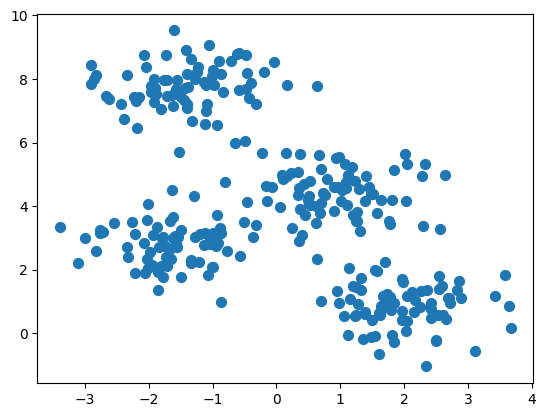

In [5]:
plt.scatter(X[:, 0], X[:, 1], s=50);

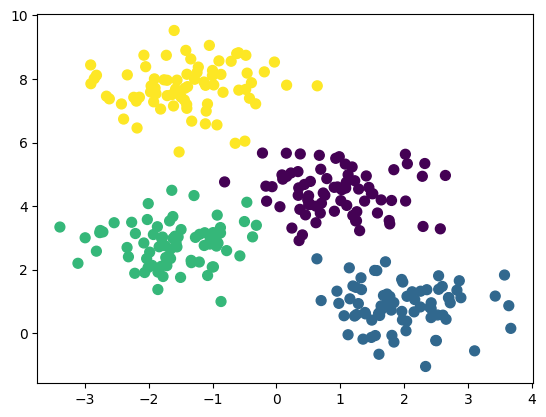

In [6]:
plt.scatter(X[:, 0], X[:, 1], s=50, c=y_true);

In [7]:
X.shape, y_true.shape

((300, 2), (300,))

### KMeans from sklearn

In [8]:
kmeans = KMeans(n_clusters=4, init='random', n_init=10)
kmeans.fit(X)
y_kmeans_1 = kmeans.predict(X)

In [9]:
y_kmeans_1

array([1, 2, 0, 2, 1, 1, 3, 0, 2, 2, 3, 2, 0, 2, 1, 0, 0, 1, 3, 3, 1, 1,
       0, 3, 3, 0, 1, 0, 3, 0, 2, 2, 0, 2, 2, 2, 2, 2, 3, 1, 0, 3, 0, 0,
       3, 3, 2, 3, 2, 1, 3, 1, 2, 1, 1, 3, 2, 3, 2, 1, 2, 0, 2, 3, 3, 3,
       2, 1, 2, 3, 0, 3, 2, 3, 3, 2, 3, 0, 1, 2, 1, 0, 1, 1, 2, 0, 1, 0,
       2, 2, 0, 1, 2, 3, 3, 0, 1, 1, 0, 3, 2, 1, 2, 1, 0, 1, 1, 0, 2, 0,
       3, 3, 1, 2, 1, 0, 2, 1, 1, 0, 3, 1, 3, 1, 1, 1, 1, 3, 1, 3, 2, 3,
       3, 1, 2, 3, 3, 2, 0, 2, 2, 3, 0, 3, 0, 3, 2, 0, 2, 2, 2, 0, 2, 0,
       1, 3, 2, 3, 1, 0, 2, 0, 0, 1, 0, 3, 3, 0, 1, 0, 0, 2, 1, 0, 3, 2,
       1, 1, 0, 3, 1, 0, 3, 3, 0, 0, 0, 0, 1, 2, 0, 3, 0, 0, 3, 3, 3, 0,
       3, 2, 0, 3, 1, 3, 0, 2, 3, 2, 0, 2, 0, 3, 0, 0, 2, 3, 3, 1, 1, 0,
       2, 1, 1, 3, 1, 3, 0, 2, 2, 0, 0, 2, 0, 1, 3, 0, 1, 3, 2, 3, 1, 0,
       1, 2, 2, 2, 2, 3, 3, 2, 0, 3, 1, 0, 3, 3, 0, 1, 1, 2, 0, 0, 3, 1,
       2, 3, 0, 2, 0, 1, 1, 3, 3, 0, 1, 1, 1, 0, 2, 2, 1, 1, 0, 1, 1, 1,
       2, 3, 2, 0, 1, 1, 2, 2, 2, 1, 1, 0, 2, 3], d

In [10]:
kmeans.score(X)

-287.59628634814646

[[ 0.92678365  4.43411574]
 [ 1.97046869  0.86272139]
 [-1.39407535  7.74006016]
 [-1.60924934  2.79866192]]


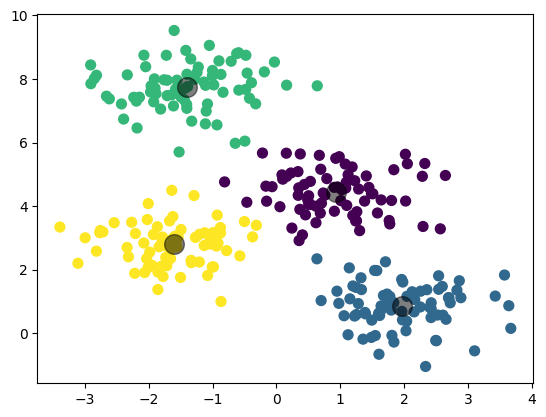

In [18]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans_1, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
print(centers)
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.5);

### KMeans implementation

In [12]:
class Kmeans:
    def __init__(self, k=4, n=1, method='random', max_iter=300):
        """k - count of clusters
        n - count of k-means models
        method - "random" or "k_means++"
        max_iter - count of iterations"""
        self.k = k 
        self.n = n
        self.method = method
        self.max_iter = max_iter
        
        self.__centroids = None
        self.__r = None
    
    def __init_centers(self, X):
        
        if self.method == 'random':
            self.__r = [random.choice(X) for i in range(self.k)]
            return self.__r
        
        if self.method == 'k-means++':
            centroids = [X[np.random.choice(len(X))]]
            while len(centroids) < self.k:
                dist = pairwise_distances(X, centroids).min(axis=1)
                new_i = np.random.choice(len(X), p=(dist ** 2).reshape(-1) / sum(dist ** 2))
                centroids.append(X[new_i])
            self.__r = np.array(centroids)
            return self.__r
    
    def fit(self, X):
        if self.n == 1:
            a = 0
            self.__centroids = self.__init_centers(X)
            for _ in range(self.max_iter):
                clusters = self.__expectation(X, self.__centroids)
                new_centroids = self.__maximization(X, clusters)
                a += 1
                new_centroids = np.array(new_centroids)
#                 if np.array_equal(new_centroids, self.__centroids):
                if (new_centroids == self.__centroids).all():
                    break
                self.__centroids = new_centroids
            print(f"Iterations: {a}")
        
        else:
            clusters_dict = {}
            for i in range(self.n):
                a = 0
                self.__centroids = self.__init_centers(X)
                for _ in range(self.max_iter):
                    clusters = self.__expectation(X, self.__centroids)
                    new_centroids = self.__maximization(X, clusters)
                    a += 1
                    new_centroids = np.array(new_centroids)
                    if (new_centroids == self.__centroids).all():
                        break
                    self.__centroids = new_centroids

                    clusters_f = self.__expectation(X, self.__centroids)
                    clust = 0
                    for cl in range(self.k):
                        ind = np.where(np.isin(clusters_f, cl))
                        cl_points = X[ind]
                        s = 0
                        for j in cl_points:
                            s += (np.sum((j - self.__centroids[cl]) ** 2)) ** 0.5
                        clust += s
                    clusters_dict[clust] = self.__centroids

                print(f"Iterations: {a}")

            for key, value in clusters_dict.items():
                if key == min(clusters_dict.keys()):
                    self.__centroids = value
            
    def __expectation(self, X, centroids):
        # return pairwise_distances_argmin(X, centroids)

        clusters = []
        for i in X:
            k = []
            for j in range(self.k):
                k.append((np.sum((i - centroids[j]) ** 2)) ** 0.5)
            clusters.append(np.argmin(k))
        return clusters

    def __maximization(self, X, clusters):
        # return  np.array([X[clusters == i].mean(axis=0) if np.any(clusters == i) else self.__centroids[i] for i in range(self.k)])
        
        new_centers = []
        for cl in range(self.k):
            ind = np.where(np.isin(clusters, cl))
            try:
                new_centers.append(sum(X[ind]) / len(X[ind]))
            except ZeroDivisionError:
                new_centers.append(np.zeros((2,)))
        return new_centers   
    
    def predict(self, X):
        if self.__centroids is None:
            print("The model is not yet trained")
            return
        clusters_final = self.__expectation(X, self.__centroids)
        return clusters_final
    
    def fit_predict(self, X):
        self.fit(X)
        clusters_final = self.predict(X)
        return clusters_final
    
    @property
    def centroids(self):
        if self.__centroids is not None:
            return self.__centroids
        else:
            return 'The centers have not yet been defined.'
    
    @property
    def centroids_random(self):
        if self.__r is not None:
            return np.array(self.__r)
        else:
            return 'The centers have not yet been defined.'

In [13]:
kmeans1 = Kmeans(k=4, n=5, method='random', max_iter=100)
kmeans1.fit(X)
y_kmeans = kmeans1.predict(X)

Iterations: 6
Iterations: 5
Iterations: 7
Iterations: 17
Iterations: 5


In [14]:
# y_kmeans

In [17]:
centers1 = model.cluster_centers_
centers1

NameError: name 'model' is not defined

In [78]:
centers_r = kmeans1.centroids_random
centers_r .cluster_centers_

array([[-1.53788149,  3.03053198],
       [ 2.28356135,  4.93801859],
       [ 1.07710058,  5.32177878],
       [ 0.50554777,  4.05210011]])

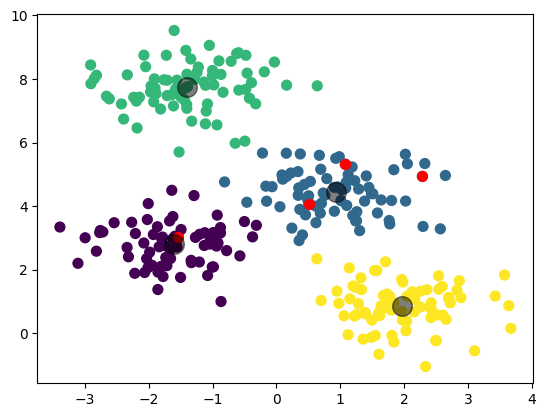

In [79]:
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
plt.scatter(centers_r[:, 0], centers_r[:, 1], c='red', s=50, alpha=1)
plt.scatter(centers1[:, 0], centers1[:, 1], c='black', s=200, alpha=0.5);

#### Prediction on new data

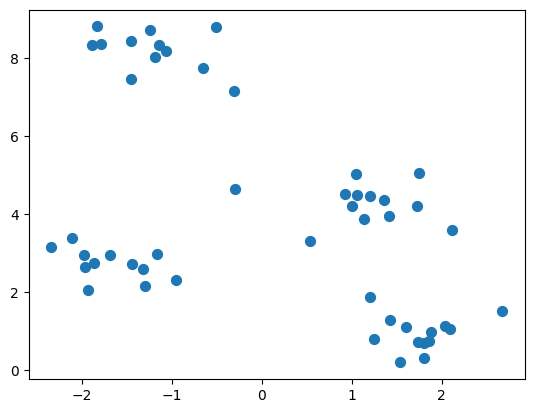

In [80]:
X_new, y_true = make_blobs(n_samples=50, centers=4, cluster_std=0.5, random_state=0)
plt.scatter(X_new[:, 0], X_new[:, 1], s=50);

In [81]:
y_kmeans_new = kmeans1.predict(X_new)

In [82]:
# y_kmeans_new

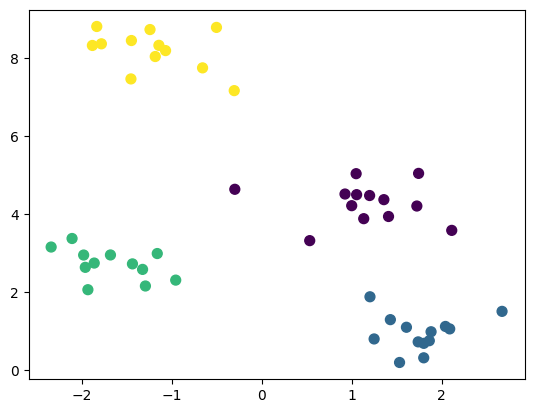

In [83]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y_true, s=50, cmap='viridis');

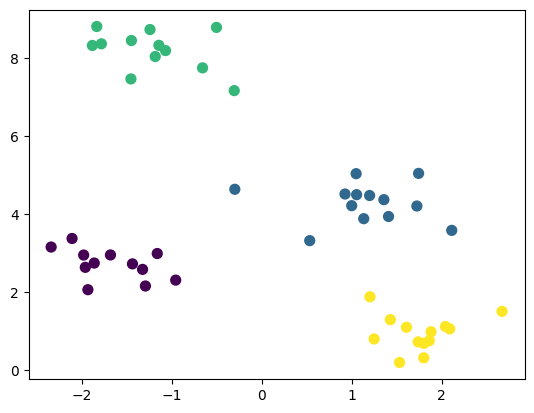

In [84]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y_kmeans_new, s=50, cmap='viridis');